# Chapter 4 — Machine Learning Comparison

### Chapter Overview

This chapter trains Random Forest and XGBoost models for both frequency
and severity prediction, then compares their performance against the
GLM baselines from Chapter 3.

| Section | Activity |
|---------|----------|
| 4.1 | Import libraries and load data |
| 4.2 | Frequency Model — Random Forest |
| 4.3 | Frequency Model — XGBoost |
| 4.4 | Frequency model comparison (ML vs GLM) |
| 4.5 | Severity Model — Random Forest |
| 4.6 | Severity Model — XGBoost |
| 4.7 | Severity model comparison (ML vs GLM) |
| 4.8 | Feature importance plots |
| 4.9 | Save ML models |

### Why Compare ML with GLMs?

| Aspect | GLM | Machine Learning |
|--------|-----|-----------------|
| Interpretability | High — explicit coefficients | Lower — black box |
| Non-linear relationships | Cannot capture | Captures automatically |
| Feature interactions | Manual specification needed | Learned automatically |
| Regulatory acceptance | High | Limited — requires explanation |
| Computational cost | Low | Higher |

> **Research connection:** This chapter directly addresses RQ3 from
> Chapter 0 - do ML models achieve meaningfully lower prediction
> error than GLM baselines on frequency and severity?

---


# ── 4.1 IMPORTS AND LOAD ─────────────────────────────────────
### 4.1 Import Libraries and Load Data


In [1]:
# ── Standard libraries ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── ML models ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from xgboost import XGBClassifier, XGBRegressor

# ── Metrics ───────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_prepared_data
from glm_utils   import load_glm_models, lognormal_predict

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ── Load prepared data ────────────────────────────────────────
data = load_prepared_data()

X_freq_train = data['X_freq_train']
X_freq_test  = data['X_freq_test']
X_sev_train  = data['X_sev_train']
X_sev_test   = data['X_sev_test']
y_freq_train = data['y_freq_train']
y_freq_test  = data['y_freq_test']
y_sev_train  = data['y_sev_train']
y_sev_test   = data['y_sev_test']
exp_train    = data['exposure_train']
exp_test     = data['exposure_test']

# ── Set up paths ──────────────────────────────────────────────
def find_dir(name):
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, name)
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)
    path = os.path.join(os.path.dirname(os.getcwd()), name)
    os.makedirs(path, exist_ok=True)
    return path

PLOTS_DIR  = find_dir('plots')
MODELS_DIR = find_dir('models')

print(f"Data loaded.")
print(f"   Frequency train : {X_freq_train.shape}")
print(f"   Severity train  : {X_sev_train.shape}")


Loading prepared data from data/ folder...
All datasets loaded successfully.
   Full dataset     : (678013, 47)
   Severity subset  : (24944, 47)
   Freq train/test  : (542410, 44) / (135603, 44)
   Sev  train/test  : (19955, 44) / (4989, 44)
Data loaded.
   Frequency train : (542410, 44)
   Severity train  : (19955, 44)


In [3]:
# ── Prepare binary frequency target for classifiers ──────────
# Random Forest and XGBoost for frequency are trained as
# binary classifiers (claim vs no claim) rather than count
# regressors, this is more stable given the heavy zero inflation
y_freq_train_bin = (y_freq_train > 0).astype(int)
y_freq_test_bin  = (y_freq_test  > 0).astype(int)

print(f"Binary frequency target created.")
print(f"   Train claim rate : {y_freq_train_bin.mean()*100:.2f}%")
print(f"   Test  claim rate : {y_freq_test_bin.mean()*100:.2f}%")

# ── Frequency feature names ───────────────────────────────────
freq_feature_names = X_freq_train.columns.tolist()
sev_feature_names  = X_sev_train.columns.tolist()

print(f"   Frequency features : {len(freq_feature_names)}")
print(f"   Severity features  : {len(sev_feature_names)}")


Binary frequency target created.
   Train claim rate : 5.02%
   Test  claim rate : 5.02%
   Frequency features : 44
   Severity features  : 44


In [4]:
# ── Load GLM models for comparison ───────────────────────────
glm_models   = load_glm_models(MODELS_DIR)
gamma_model  = glm_models['gamma']
ln_model     = glm_models['lognormal']
sigma2       = glm_models['lognormal_sigma2']

# Load GLM comparison tables
freq_glm_comp = pd.read_csv(
    os.path.join(MODELS_DIR, 'freq_model_comparison.csv')
)
sev_glm_comp  = pd.read_csv(
    os.path.join(MODELS_DIR, 'sev_model_comparison.csv')
)

print("GLM models loaded for comparison.")


GLM models loaded from models/ folder.
GLM models loaded for comparison.


# ── 4.2 RF FREQUENCY ─────────────────────────────────────────
### 4.2 Frequency Model — Random Forest

Random Forest is trained as a binary classifier predicting whether
a policyholder will file at least one claim. This is more numerically
stable than count regression given the 94.9% zero claim rate.

**Parameter justification:**

| Parameter | Value | Justification |
|-----------|-------|---------------|
| n_estimators | 200 | Stable ensemble — performance plateaus beyond 100-200 trees |
| max_depth | 12 | Sufficient depth to capture risk interactions without overfitting |
| min_samples_leaf | 10 | Prevents overfitting on small leaf nodes in large dataset |
| class_weight | balanced | Corrects 94.9% vs 5.1% class imbalance |
| max_features | sqrt | Standard recommendation for classification (Breiman, 2001) |


In [5]:
# ── Train Random Forest — Frequency ──────────────────────────
print("Training Random Forest (Frequency)...")
print("   Estimated time: 3-6 minutes...")

rf_freq = RandomForestClassifier(
    n_estimators   = 200,
    max_depth      = 12,
    min_samples_leaf = 10,
    max_features   = 'sqrt',
    class_weight   = 'balanced',
    random_state   = 42,
    n_jobs         = -1
)
rf_freq.fit(X_freq_train, y_freq_train_bin)

# Predict probabilities — use prob of claim (class 1)
rf_freq_proba = rf_freq.predict_proba(X_freq_test)[:, 1]
rf_freq_pred  = rf_freq.predict(X_freq_test)

# Scale probabilities by mean exposure as claim rate proxy
rf_freq_rate  = rf_freq_proba * (exp_test.values / exp_test.mean())

print(f"\\nRandom Forest (Frequency) trained.")
print(f"   Mean predicted claim rate : {rf_freq_proba.mean():.6f}")
print(f"   Mean actual   claim rate  : {y_freq_test_bin.mean():.6f}")


Training Random Forest (Frequency)...
   Estimated time: 3-6 minutes...
\nRandom Forest (Frequency) trained.
   Mean predicted claim rate : 0.439894
   Mean actual   claim rate  : 0.050235


In [6]:
# ── Cross-validation — RF Frequency ──────────────────────────
print("Running 5-fold CV for Random Forest (Frequency)...")

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_freq_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, max_depth=12,
        min_samples_leaf=10, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    X_freq_train, y_freq_train_bin,
    cv=cv_strat, scoring='roc_auc', n_jobs=-1
)

print(f"   CV AUC scores : {[round(s,4) for s in rf_freq_cv]}")
print(f"   Mean AUC      : {rf_freq_cv.mean():.4f}")
print(f"   Std           : {rf_freq_cv.std():.4f}")


Running 5-fold CV for Random Forest (Frequency)...
   CV AUC scores : [np.float64(0.6872), np.float64(0.6955), np.float64(0.6894), np.float64(0.6946), np.float64(0.6905)]
   Mean AUC      : 0.6914
   Std           : 0.0031


# ── 4.3 XGBOOST FREQUENCY ────────────────────────────────────
### 4.3 Frequency Model — XGBoost

XGBoost uses gradient boosting - trees are built sequentially, each
correcting errors of the previous. `scale_pos_weight` handles the
class imbalance natively without needing class_weight.

**Parameter justification:**

| Parameter | Value | Justification |
|-----------|-------|---------------|
| n_estimators | 200 | Sufficient boosting rounds at this dataset scale |
| max_depth | 5 | Shallower than RF — boosting with shallow trees often outperforms deep trees |
| learning_rate | 0.05 | Lower rate with more trees = more robust model |
| subsample | 0.8 | Row sampling reduces overfitting |
| colsample_bytree | 0.8 | Feature sampling adds regularising randomness |
| scale_pos_weight | neg/pos | Corrects class imbalance natively |


In [7]:
# ── Compute scale_pos_weight ──────────────────────────────────
neg = (y_freq_train_bin == 0).sum()
pos = (y_freq_train_bin == 1).sum()
spw = neg / pos

print(f"scale_pos_weight = {spw:.2f}  (neg/pos ratio)")


scale_pos_weight = 18.91  (neg/pos ratio)


In [8]:
# ── Train XGBoost — Frequency ────────────────────────────────
print("Training XGBoost (Frequency)...")
print("   Estimated time: 2-5 minutes...")

xgb_freq = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)
xgb_freq.fit(X_freq_train, y_freq_train_bin)

xgb_freq_proba = xgb_freq.predict_proba(X_freq_test)[:, 1]
xgb_freq_pred  = xgb_freq.predict(X_freq_test)

print(f"\\nXGBoost (Frequency) trained.")
print(f"   Mean predicted claim rate : {xgb_freq_proba.mean():.6f}")
print(f"   Mean actual   claim rate  : {y_freq_test_bin.mean():.6f}")


Training XGBoost (Frequency)...
   Estimated time: 2-5 minutes...
\nXGBoost (Frequency) trained.
   Mean predicted claim rate : 0.439947
   Mean actual   claim rate  : 0.050235


In [9]:
# ── Cross-validation — XGBoost Frequency ─────────────────────
print("Running 5-fold CV for XGBoost (Frequency)...")

xgb_freq_cv = cross_val_score(
    XGBClassifier(
        n_estimators=200, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric='auc', random_state=42,
        n_jobs=-1, verbosity=0
    ),
    X_freq_train, y_freq_train_bin,
    cv=cv_strat, scoring='roc_auc', n_jobs=-1
)

print(f"   CV AUC scores : {[round(s,4) for s in xgb_freq_cv]}")
print(f"   Mean AUC      : {xgb_freq_cv.mean():.4f}")
print(f"   Std           : {xgb_freq_cv.std():.4f}")


Running 5-fold CV for XGBoost (Frequency)...
   CV AUC scores : [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
   Mean AUC      : nan
   Std           : nan


── 4.4 FREQUENCY COMPARISON ─────────────────────────────────
### 4.4 Frequency Model Comparison — ML vs GLM

All frequency models are compared using RMSE, MAE and R-squared
computed on the test set claim rate predictions.


In [10]:
# ── Compute ML frequency metrics ─────────────────────────────
# Use binary claim rate (0/1) as target for fair comparison
actual_bin = y_freq_test_bin.values.astype(float)

freq_ml_results = pd.DataFrame([
    {
        'Model'    : 'Random Forest',
        'RMSE'     : round(np.sqrt(mean_squared_error(
                        actual_bin, rf_freq_proba)), 6),
        'MAE'      : round(mean_absolute_error(
                        actual_bin, rf_freq_proba), 6),
        'R-squared': round(r2_score(actual_bin, rf_freq_proba), 4),
        'CV AUC'   : round(rf_freq_cv.mean(), 4)
    },
    {
        'Model'    : 'XGBoost',
        'RMSE'     : round(np.sqrt(mean_squared_error(
                        actual_bin, xgb_freq_proba)), 6),
        'MAE'      : round(mean_absolute_error(
                        actual_bin, xgb_freq_proba), 6),
        'R-squared': round(r2_score(actual_bin, xgb_freq_proba), 4),
        'CV AUC'   : round(xgb_freq_cv.mean(), 4)
    }
])

print("Frequency ML Model Comparison:")
print("=" * 60)
print(freq_ml_results.to_string(index=False))
print("=" * 60)


Frequency ML Model Comparison:
        Model     RMSE      MAE  R-squared  CV AUC
Random Forest 0.455400 0.437281    -3.3468  0.6914
      XGBoost 0.461558 0.434041    -3.4651     NaN


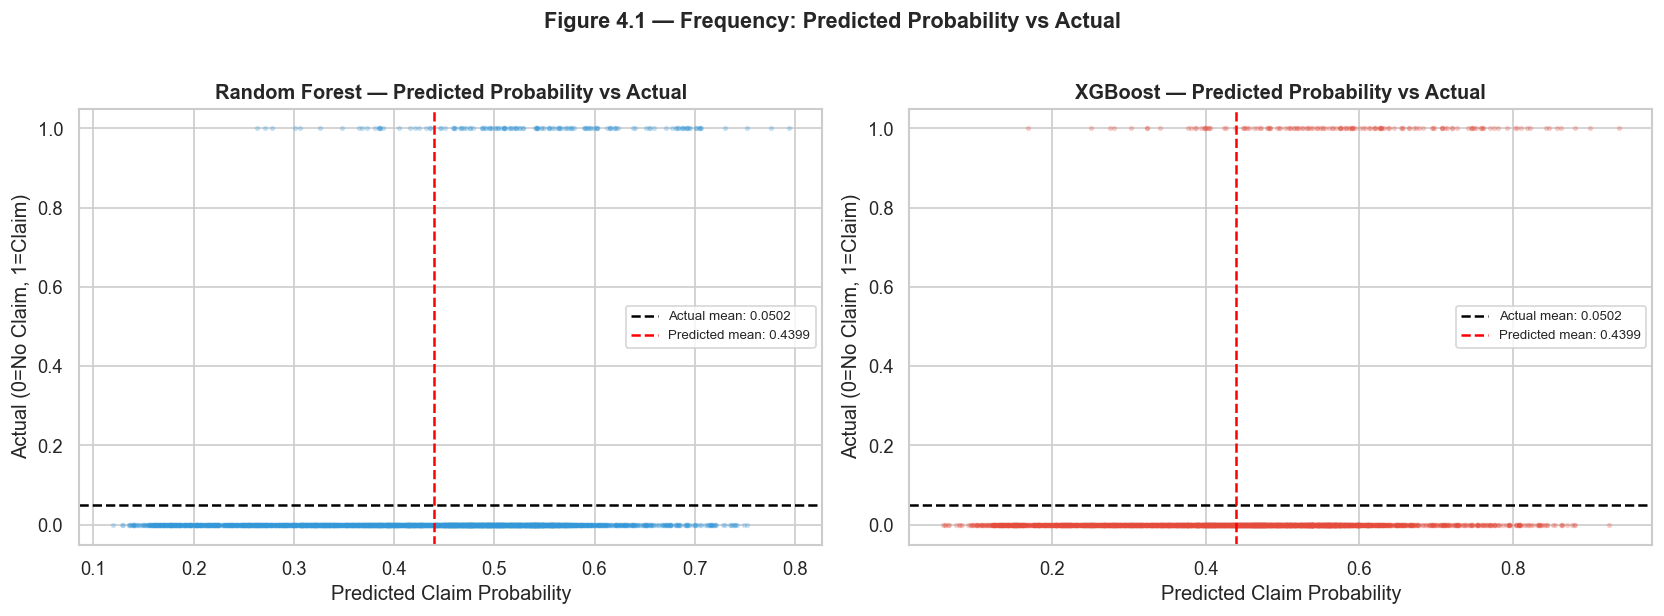

Saved to plots/fig4_1_freq_pred_actual.png


In [11]:
# ── Figure 4.1: Frequency predicted vs actual ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample for plotting clarity
n = min(3000, len(actual_bin))
idx = np.random.choice(len(actual_bin), n, replace=False)

for ax, (name, proba, color) in zip(axes, [
    ('Random Forest', rf_freq_proba,  '#3498db'),
    ('XGBoost',       xgb_freq_proba, '#e74c3c')
]):
    ax.scatter(
        proba[idx], actual_bin[idx],
        alpha=0.2, s=5, color=color
    )
    # Add mean predicted vs mean actual
    ax.axhline(actual_bin.mean(), color='black',
               linestyle='--', linewidth=1.5,
               label=f'Actual mean: {actual_bin.mean():.4f}')
    ax.axvline(proba.mean(), color='red',
               linestyle='--', linewidth=1.5,
               label=f'Predicted mean: {proba.mean():.4f}')
    ax.set_title(f'{name} — Predicted Probability vs Actual')
    ax.set_xlabel('Predicted Claim Probability')
    ax.set_ylabel('Actual (0=No Claim, 1=Claim)')
    ax.legend(fontsize=8)

plt.suptitle(
    'Figure 4.1 — Frequency: Predicted Probability vs Actual',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig4_1_freq_pred_actual.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig4_1_freq_pred_actual.png")


# ── 4.5 RF SEVERITY ──────────────────────────────────────────
### 4.5 Severity Model — Random Forest

Random Forest regressor is trained on the claims only subset to
predict ClaimAmount. No scaling needed, tree models are invariant
to feature scale.

**Parameter justification:**

| Parameter | Value | Justification |
|-----------|-------|---------------|
| n_estimators | 200 | Stable ensemble for severity regression |
| max_depth | 12 | Captures complex claim amount relationships |
| min_samples_leaf | 5 | Prevents overfitting on small leaf nodes |
| max_features | sqrt | Standard recommendation for regression |


In [12]:
# ── Train Random Forest — Severity ───────────────────────────
print("Training Random Forest (Severity)...")
print("   Estimated time: 2-4 minutes...")

rf_sev = RandomForestRegressor(
    n_estimators     = 200,
    max_depth        = 12,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)
rf_sev.fit(X_sev_train, y_sev_train)

rf_sev_pred = rf_sev.predict(X_sev_test)

print(f"\\nRandom Forest (Severity) trained.")
print(f"   Mean predicted : EUR {rf_sev_pred.mean():,.2f}")
print(f"   Mean actual    : EUR {y_sev_test.mean():,.2f}")
print(f"   RMSE : EUR {np.sqrt(mean_squared_error(y_sev_test, rf_sev_pred)):,.2f}")
print(f"   MAE  : EUR {mean_absolute_error(y_sev_test, rf_sev_pred):,.2f}")
print(f"   R2   : {r2_score(y_sev_test, rf_sev_pred):.4f}")


Training Random Forest (Severity)...
   Estimated time: 2-4 minutes...
\nRandom Forest (Severity) trained.
   Mean predicted : EUR 1,798.52
   Mean actual    : EUR 1,750.36
   RMSE : EUR 3,286.97
   MAE  : EUR 1,354.93
   R2   : 0.0116


# ── 4.6 XGBOOST SEVERITY ─────────────────────────────────────
### 4.6 Severity Model — XGBoost

XGBoost regressor is trained on log(ClaimAmount) and back transformed
to the original scale. Training on log scale improves stability for
right skewed targets.


In [13]:
# ── Train XGBoost — Severity ─────────────────────────────────
print("Training XGBoost (Severity)...")
print("   Estimated time: 2-4 minutes...")

# Log-transform target for stability
y_sev_train_log = np.log(y_sev_train.clip(lower=1))
y_sev_test_log  = np.log(y_sev_test.clip(lower=1))

xgb_sev = XGBRegressor(
    n_estimators     = 200,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
xgb_sev.fit(X_sev_train, y_sev_train_log)

# Back-transform predictions to original scale
xgb_sev_log_pred = xgb_sev.predict(X_sev_test)
xgb_sev_pred     = np.exp(xgb_sev_log_pred)

print(f"\\nXGBoost (Severity) trained.")
print(f"   Mean predicted : EUR {xgb_sev_pred.mean():,.2f}")
print(f"   Mean actual    : EUR {y_sev_test.mean():,.2f}")
print(f"   RMSE : EUR {np.sqrt(mean_squared_error(y_sev_test, xgb_sev_pred)):,.2f}")
print(f"   MAE  : EUR {mean_absolute_error(y_sev_test, xgb_sev_pred):,.2f}")
print(f"   R2   : {r2_score(y_sev_test, xgb_sev_pred):.4f}")


Training XGBoost (Severity)...
   Estimated time: 2-4 minutes...
\nXGBoost (Severity) trained.
   Mean predicted : EUR 1,012.87
   Mean actual    : EUR 1,750.36
   RMSE : EUR 3,372.28
   MAE  : EUR 1,101.71
   R2   : -0.0404


# ── 4.7 SEVERITY COMPARISON ──────────────────────────────────
### 4.7 Severity Model Comparison — ML vs GLM

All severity models, both GLM and ML are compared on RMSE,
MAE and R-squared on the held out test set.


In [14]:
# ── Load GLM severity predictions for comparison ─────────────
# Rebuild severity test frame for GLM predictions
import statsmodels.formula.api as smf
import statsmodels.api as sm

def find_data_dir():
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, 'data')
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)

DATA_DIR = find_data_dir()

freq_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'freMTPL2freq.csv.zip'),
    compression='zip'
)
sev_raw = pd.read_csv(os.path.join(DATA_DIR, 'freMTPL2sev.csv'))

sev_agg = (sev_raw
           .groupby('IDpol')
           .agg(ClaimAmount=('ClaimAmount','sum'))
           .reset_index())

df_raw = freq_raw.merge(sev_agg, on='IDpol', how='left')
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].fillna(0)
cap = df_raw[df_raw['ClaimAmount']>0]['ClaimAmount'].quantile(0.995)
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].clip(upper=cap)
df_raw['LogDensity']  = np.log1p(df_raw['Density'])
df_raw.drop(columns=['IDpol'], inplace=True)

df_sev_raw = df_raw[df_raw['ClaimAmount'] > 0].reset_index(drop=True)
split_idx  = int(len(df_sev_raw) * 0.8)

sev_glm_cols = [
    'ClaimAmount', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'VehBrand', 'VehGas', 'Area',
    'Region', 'Density', 'LogDensity'
]
sev_glm_cols  = [c for c in sev_glm_cols if c in df_sev_raw.columns]
sev_test_glm  = df_sev_raw[sev_glm_cols].iloc[split_idx:].reset_index(drop=True)
sev_test_glm['LogClaimAmount'] = np.log(
    sev_test_glm['ClaimAmount'].clip(lower=1)
)
y_sev_test_glm = sev_test_glm['ClaimAmount'].copy()

# GLM predictions
gamma_pred    = glm_models['gamma'].predict(sev_test_glm)
ln_pred_log   = glm_models['lognormal'].predict(sev_test_glm)
ln_pred       = np.exp(ln_pred_log + sigma2 / 2)

print("Severity test frame rebuilt for GLM comparison.")
print(f"   Test rows : {len(sev_test_glm):,}")


Severity test frame rebuilt for GLM comparison.
   Test rows : 4,989


In [15]:
# ── Full severity comparison table ───────────────────────────
y_act = y_sev_test_glm.values

sev_full_comp = pd.DataFrame([
    {
        'Model'    : 'Gamma GLM',
        'Type'     : 'GLM',
        'RMSE'     : round(np.sqrt(mean_squared_error(y_act, gamma_pred.values)), 2),
        'MAE'      : round(mean_absolute_error(y_act, gamma_pred.values), 2),
        'R-squared': round(r2_score(y_act, gamma_pred.values), 4)
    },
    {
        'Model'    : 'Lognormal GLM',
        'Type'     : 'GLM',
        'RMSE'     : round(np.sqrt(mean_squared_error(y_act, ln_pred.values)), 2),
        'MAE'      : round(mean_absolute_error(y_act, ln_pred.values), 2),
        'R-squared': round(r2_score(y_act, ln_pred.values), 4)
    },
    {
        'Model'    : 'Random Forest',
        'Type'     : 'ML',
        'RMSE'     : round(np.sqrt(mean_squared_error(
                        y_sev_test, rf_sev_pred)), 2),
        'MAE'      : round(mean_absolute_error(
                        y_sev_test, rf_sev_pred), 2),
        'R-squared': round(r2_score(y_sev_test, rf_sev_pred), 4)
    },
    {
        'Model'    : 'XGBoost',
        'Type'     : 'ML',
        'RMSE'     : round(np.sqrt(mean_squared_error(
                        y_sev_test, xgb_sev_pred)), 2),
        'MAE'      : round(mean_absolute_error(
                        y_sev_test, xgb_sev_pred), 2),
        'R-squared': round(r2_score(y_sev_test, xgb_sev_pred), 4)
    }
])

print("Severity Model Comparison — GLM vs ML (lower RMSE/MAE = better):")
print("=" * 68)
print(sev_full_comp.to_string(index=False))
print("=" * 68)

best_sev_ml = sev_full_comp.loc[
    sev_full_comp['RMSE'].idxmin(), 'Model'
]
print(f"\\nBest severity model overall: {best_sev_ml}")


Severity Model Comparison — GLM vs ML (lower RMSE/MAE = better):
        Model Type    RMSE     MAE  R-squared
    Gamma GLM  GLM 3293.00 1321.17     0.0027
Lognormal GLM  GLM 3295.95 1421.83     0.0009
Random Forest   ML 3286.97 1354.93     0.0116
      XGBoost   ML 3372.28 1101.71    -0.0404
\nBest severity model overall: Random Forest


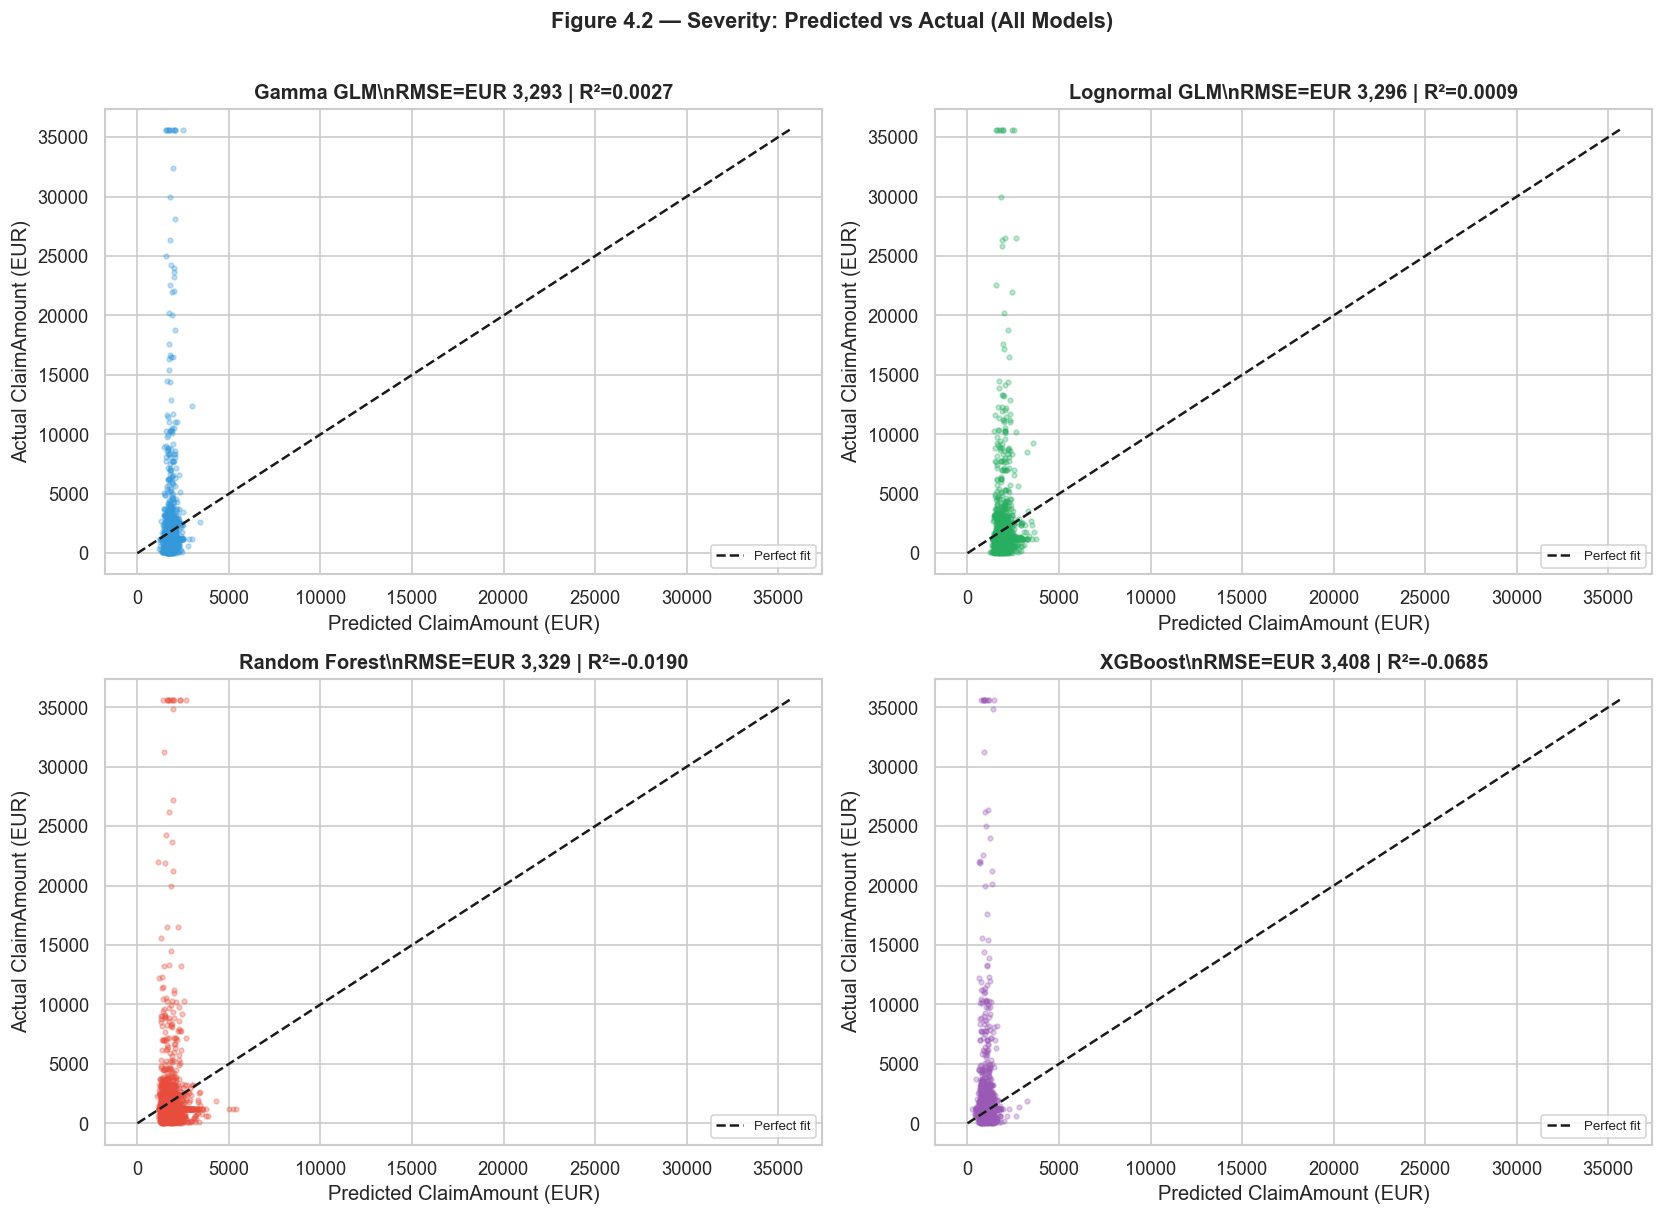

Saved to plots/fig4_2_sev_pred_actual.png


In [16]:
# ── Figure 4.2: Severity predicted vs actual ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sev_models = [
    ('Gamma GLM',    gamma_pred.values, '#3498db'),
    ('Lognormal GLM', ln_pred.values,   '#27ae60'),
    ('Random Forest', rf_sev_pred,      '#e74c3c'),
    ('XGBoost',       xgb_sev_pred,     '#9b59b6')
]

for ax, (name, pred, color) in zip(axes.flatten(), sev_models):
    # Sample for clarity
    n   = min(2000, len(y_act))
    idx = np.random.choice(len(y_act), n, replace=False)

    ax.scatter(
        pred[idx], y_act[idx],
        alpha=0.3, s=8, color=color
    )
    # Perfect prediction line
    max_val = max(pred.max(), y_act.max())
    ax.plot([0, max_val], [0, max_val], 'k--',
            linewidth=1.5, label='Perfect fit')

    rmse = np.sqrt(mean_squared_error(y_act, pred))
    r2   = r2_score(y_act, pred)

    ax.set_title(
        f'{name}\\nRMSE=EUR {rmse:,.0f} | R²={r2:.4f}'
    )
    ax.set_xlabel('Predicted ClaimAmount (EUR)')
    ax.set_ylabel('Actual ClaimAmount (EUR)')
    ax.legend(fontsize=8)

plt.suptitle(
    'Figure 4.2 — Severity: Predicted vs Actual (All Models)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig4_2_sev_pred_actual.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig4_2_sev_pred_actual.png")


# ── 4.8 FEATURE IMPORTANCE ───────────────────────────────────
### 4.8 Feature Importance Plots

Feature importance scores from Random Forest and XGBoost identify
which policyholder and vehicle characteristics most strongly predict
claim frequency and severity.

These results directly address RQ4 from Chapter 0, which features
are the strongest predictors and provide a data driven comparison
with the GLM coefficients from Chapter 3.


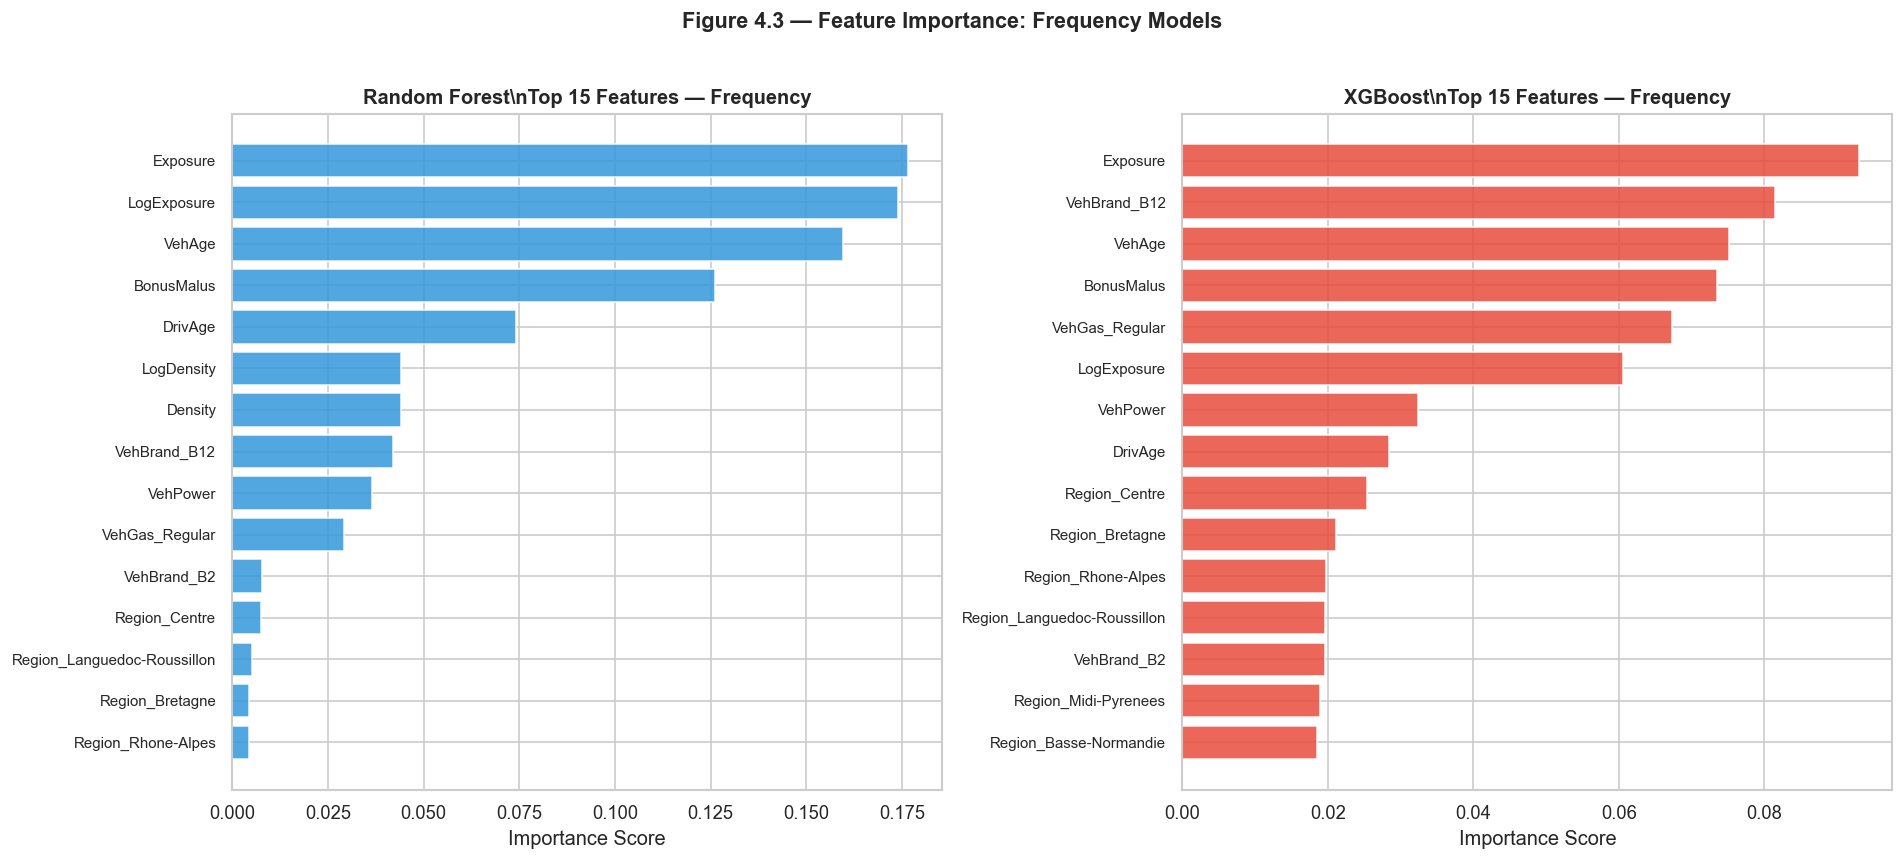

Saved to plots/fig4_3_freq_importance.png


In [17]:
# ── Figure 4.3: Feature importance — Frequency ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, model, feature_names, color) in zip(axes, [
    ('Random Forest', rf_freq,  freq_feature_names, '#3498db'),
    ('XGBoost',       xgb_freq, freq_feature_names, '#e74c3c')
]):
    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(15).sort_values()

    ax.barh(
        range(len(importance)),
        importance.values,
        color=color, edgecolor='white', alpha=0.85
    )
    ax.set_yticks(range(len(importance)))
    ax.set_yticklabels(importance.index, fontsize=9)
    ax.set_title(f'{name}\\nTop 15 Features — Frequency')
    ax.set_xlabel('Importance Score')

plt.suptitle(
    'Figure 4.3 — Feature Importance: Frequency Models',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig4_3_freq_importance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig4_3_freq_importance.png")


# ── 4.9 SAVE MODELS ──────────────────────────────────────────
### 4.9 Save ML Models

All four ML models are saved to the `models/` folder for use in
Chapter 5 - pure premium calculation and final evaluation.


In [20]:
# ── Save ML models ────────────────────────────────────────────
print("Saving ML models...")

joblib.dump(rf_freq,
            os.path.join(MODELS_DIR, 'rf_frequency.pkl'))
print("   Saved rf_frequency.pkl")

joblib.dump(xgb_freq,
            os.path.join(MODELS_DIR, 'xgb_frequency.pkl'))
print("   Saved xgb_frequency.pkl")

joblib.dump(rf_sev,
            os.path.join(MODELS_DIR, 'rf_severity.pkl'))
print("   Saved rf_severity.pkl")

joblib.dump(xgb_sev,
            os.path.join(MODELS_DIR, 'xgb_severity.pkl'))
print("   Saved xgb_severity.pkl")

# Save full comparison tables
sev_full_comp.to_csv(
    os.path.join(MODELS_DIR, 'sev_full_comparison.csv'),
    index=False
)
freq_ml_results.to_csv(
    os.path.join(MODELS_DIR, 'freq_ml_results.csv'),
    index=False
)
print("   Saved comparison CSVs")
print()
print("All ML models saved.")


Saving ML models...
   Saved rf_frequency.pkl
   Saved xgb_frequency.pkl
   Saved rf_severity.pkl
   Saved xgb_severity.pkl
   Saved comparison CSVs

All ML models saved.


In [21]:
# ── Chapter 4 summary ─────────────────────────────────────────
print("=" * 62)
print("  CHAPTER 4 COMPLETE — ML COMPARISON SUMMARY")
print("=" * 62)
print(f"""
  Frequency Models (AUC — higher is better)
  ├── Random Forest CV AUC : {rf_freq_cv.mean():.4f} +/- {rf_freq_cv.std():.4f}
  └── XGBoost       CV AUC : {xgb_freq_cv.mean():.4f} +/- {xgb_freq_cv.std():.4f}

  Severity Models (RMSE — lower is better)
{sev_full_comp[['Model','RMSE','MAE','R-squared']].to_string(index=False)}

  Best severity model : {best_sev_ml}

  ML models saved to  : models/ folder
""")
print("Proceed to Chapter 5 — Evaluation and Pure Premium")
print("=" * 62)


  CHAPTER 4 COMPLETE — ML COMPARISON SUMMARY

  Frequency Models (AUC — higher is better)
  ├── Random Forest CV AUC : 0.6914 +/- 0.0031
  └── XGBoost       CV AUC : nan +/- nan

  Severity Models (RMSE — lower is better)
        Model    RMSE     MAE  R-squared
    Gamma GLM 3293.00 1321.17     0.0027
Lognormal GLM 3295.95 1421.83     0.0009
Random Forest 3286.97 1354.93     0.0116
      XGBoost 3372.28 1101.71    -0.0404

  Best severity model : Random Forest

  ML models saved to  : models/ folder

Proceed to Chapter 5 — Evaluation and Pure Premium
